<a href="https://colab.research.google.com/github/indu00729/BloodCell/blob/main/RBC_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Install patool to extract .rar files
!pip install patool
import patoolib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 3.6 MB/s eta 0:00:00


In [2]:
# Define paths
rar_path = '/content/RBC.rar'
extract_path = '/content/extracted_images'

# Create extraction directory
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Extract the RAR file
patoolib.extract_archive(rar_path, outdir=extract_path)

INFO patool: Extracting /content/RBC.rar ...
INFO patool: running /usr/bin/unrar x -kb -or -- /content/RBC.rar
INFO patool: ... /content/RBC.rar extracted to `/content/extracted_images'.


'/content/extracted_images'

In [4]:
import os

# Path where the RAR was extracted
extract_path = '/content/extracted_images'
rbc_path = os.path.join(extract_path, 'RBC')

# Identify classes (subdirectories)
path_to_check = rbc_path if os.path.exists(rbc_path) else extract_path
classes = [d for d in os.listdir(path_to_check) if os.path.isdir(os.path.join(path_to_check, d))]

print(f"Found {len(classes)} classes in {path_to_check}:")
for cls in sorted(classes):
    print(f" - {cls}")

Found 3 classes in /content/extracted_images/RBC:
 - test
 - train
 - val


In [6]:
# List the actual classes found inside the split directories
classes_dir = os.path.join(path_to_check, 'train')
if os.path.exists(classes_dir):
    actual_classes = [d for d in os.listdir(classes_dir) if os.path.isdir(os.path.join(classes_dir, d))]
    print(f"Class types found in the dataset:")
    for c in sorted(actual_classes):
        print(f" - {c}")
else:
    print("Could not find a 'train' directory to list classes from.")

Class types found in the dataset:
 - Acanthocyte
 - Burr cell
 - Hypochromia
 - Ovalocyte
 - Schistocyte
 - Spherocyte
 - Stomatocyte
 - Target Cell
 - cigar cell
 - normal
 - teardrop


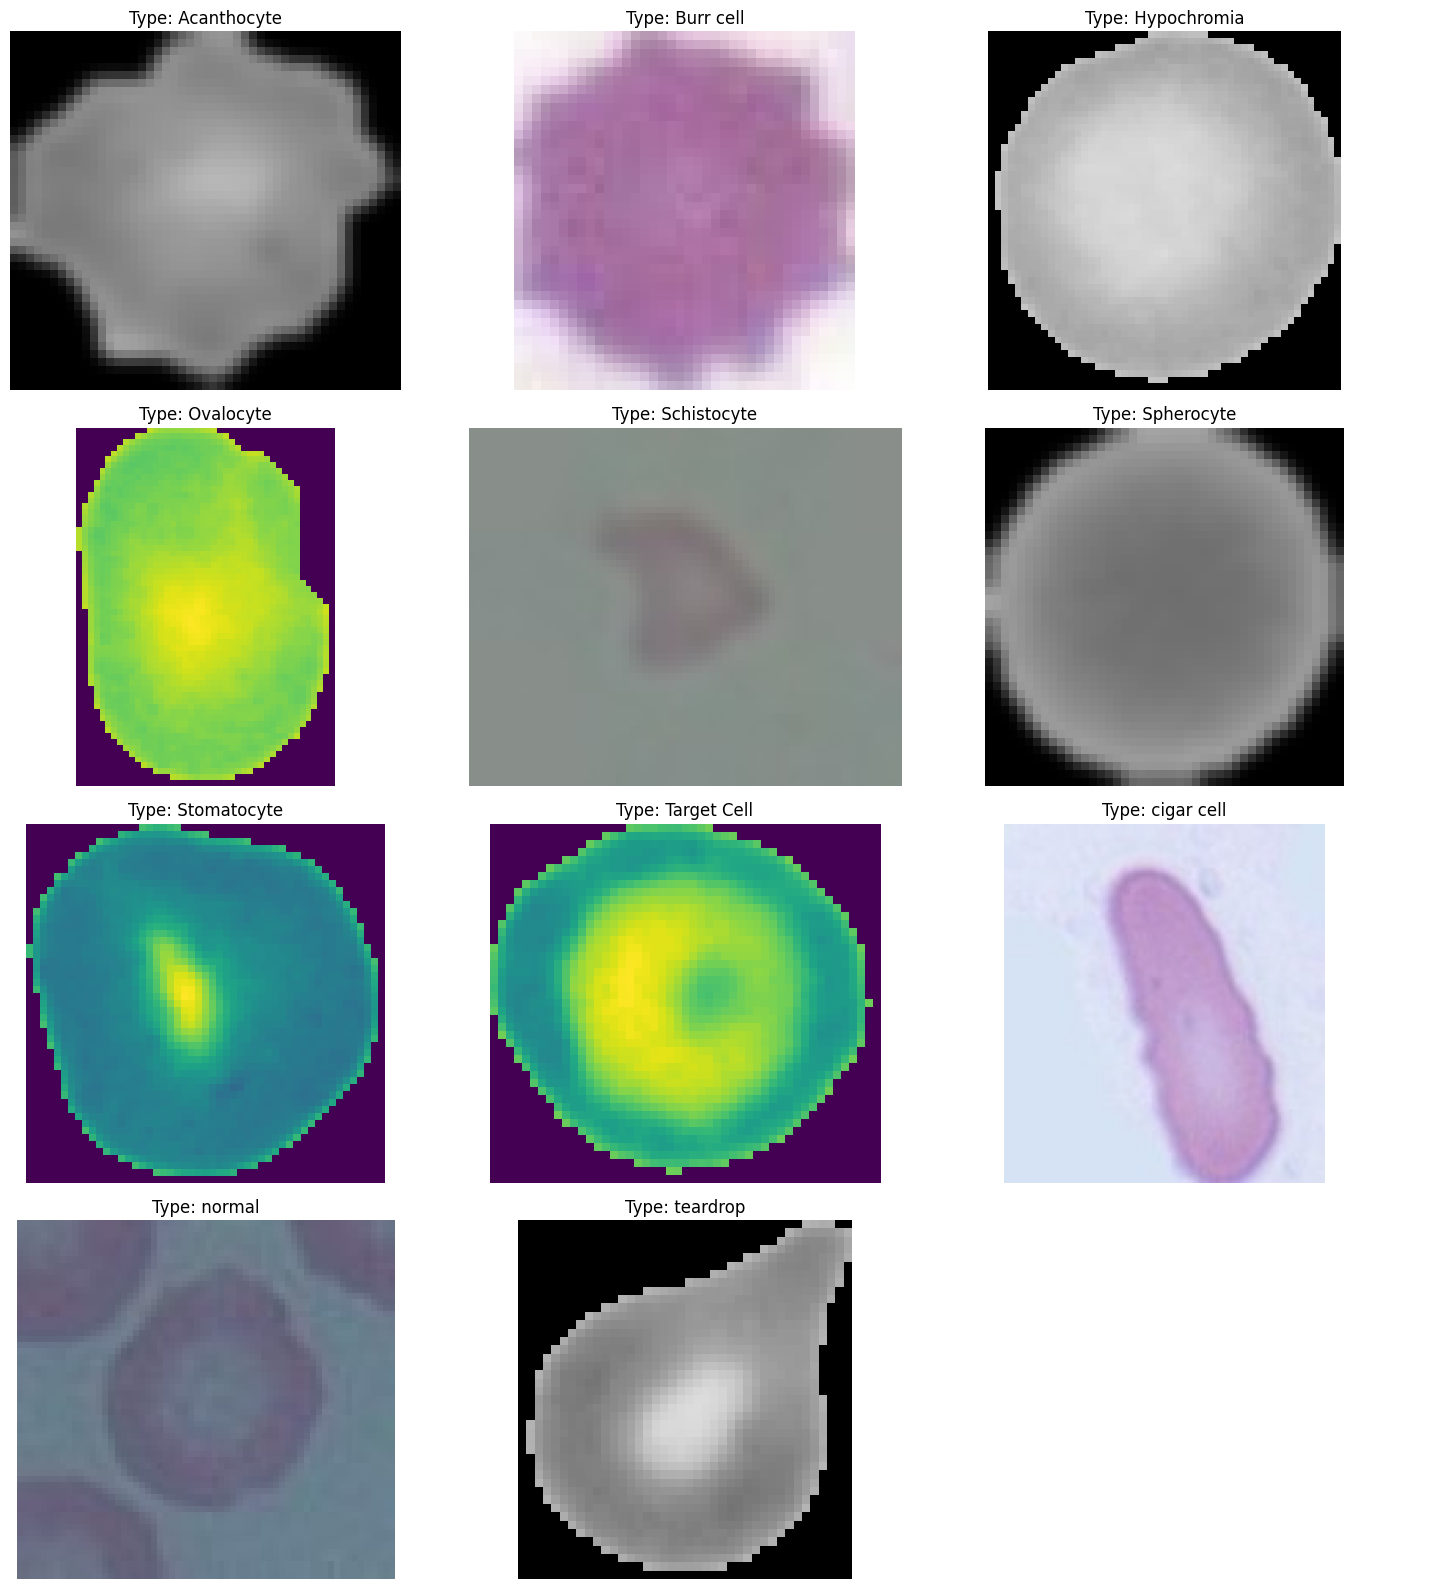

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

# We'll look into the train folder for samples
samples_dir = os.path.join(path_to_check, 'train')
classes = sorted([d for d in os.listdir(samples_dir) if os.path.isdir(os.path.join(samples_dir, d))])

# Setup the grid
cols = 3
rows = math.ceil(len(classes) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_path = os.path.join(samples_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if img_files:
        img_path = os.path.join(cls_path, img_files[0])
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"Type: {cls}")
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"No images in {cls}", ha='center')
        axes[i].axis('off')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 1. Data Preparation
We will use `tf.keras.utils.image_dataset_from_directory` to load the images. We'll set a standard image size (e.g., 128x128) and batch size.

In [8]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Define directory paths based on the previous extraction
train_path = '/content/extracted_images/RBC/train'
val_path = '/content/extracted_images/RBC/val'
test_path = '/content/extracted_images/RBC/test'

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Loaded classes: {class_names}")

Found 19940 files belonging to 11 classes.
Found 3158 files belonging to 11 classes.
Found 6240 files belonging to 11 classes.
Loaded classes: ['Acanthocyte', 'Burr cell', 'Hypochromia', 'Ovalocyte', 'Schistocyte', 'Spherocyte', 'Stomatocyte', 'Target Cell', 'cigar cell', 'normal', 'teardrop']


### 2. Model Definition
Now, we'll define a simple Convolutional Neural Network (CNN). We include a rescaling layer to normalize pixel values between 0 and 1.

In [9]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,059 (12.61 MB)

 Trainable params: 3,306,059 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6709 - loss: 0.9842 - val_accuracy: 0.7422 - val_loss: 0.8497
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7684 - loss: 0.7416 - val_accuracy: 0.7656 - val_loss: 0.7056
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7925 - loss: 0.6367 - val_accuracy: 0.7844 - val_loss: 0.6386
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8109 - loss: 0.5826 - val_accuracy: 0.7875 - val_loss: 0.6450
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8231 - loss: 0.5291 - val_accuracy: 0.8266 - val_loss: 0.5307


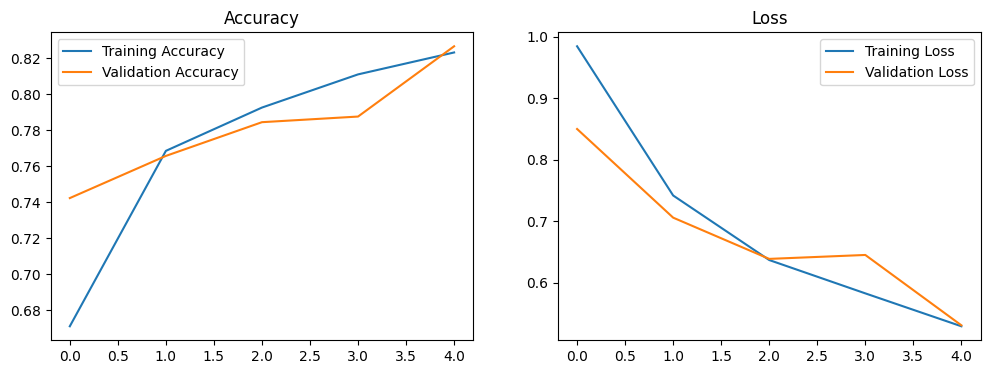

In [12]:
EPOCHS = 5
STEPS_PER_EPOCH = 100 # Adjusted from 624 to speed up training
VALIDATION_STEPS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS
)

# Visualize results
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

### 4. Model Evaluation
Now that the model is trained, let's evaluate its performance using the test dataset that was not used during training or validation.

In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

195/195 ━━━━━━━━━━━━━━━━━━━━ 56s 285ms/step - accuracy: 0.8176 - loss: 0.5302

Test accuracy: 0.8176
Test loss: 0.5302


### 5. Visualizing Real vs Predicted Labels
Let's take a sample batch from the test set and compare the model's predictions with the actual ground truth.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step


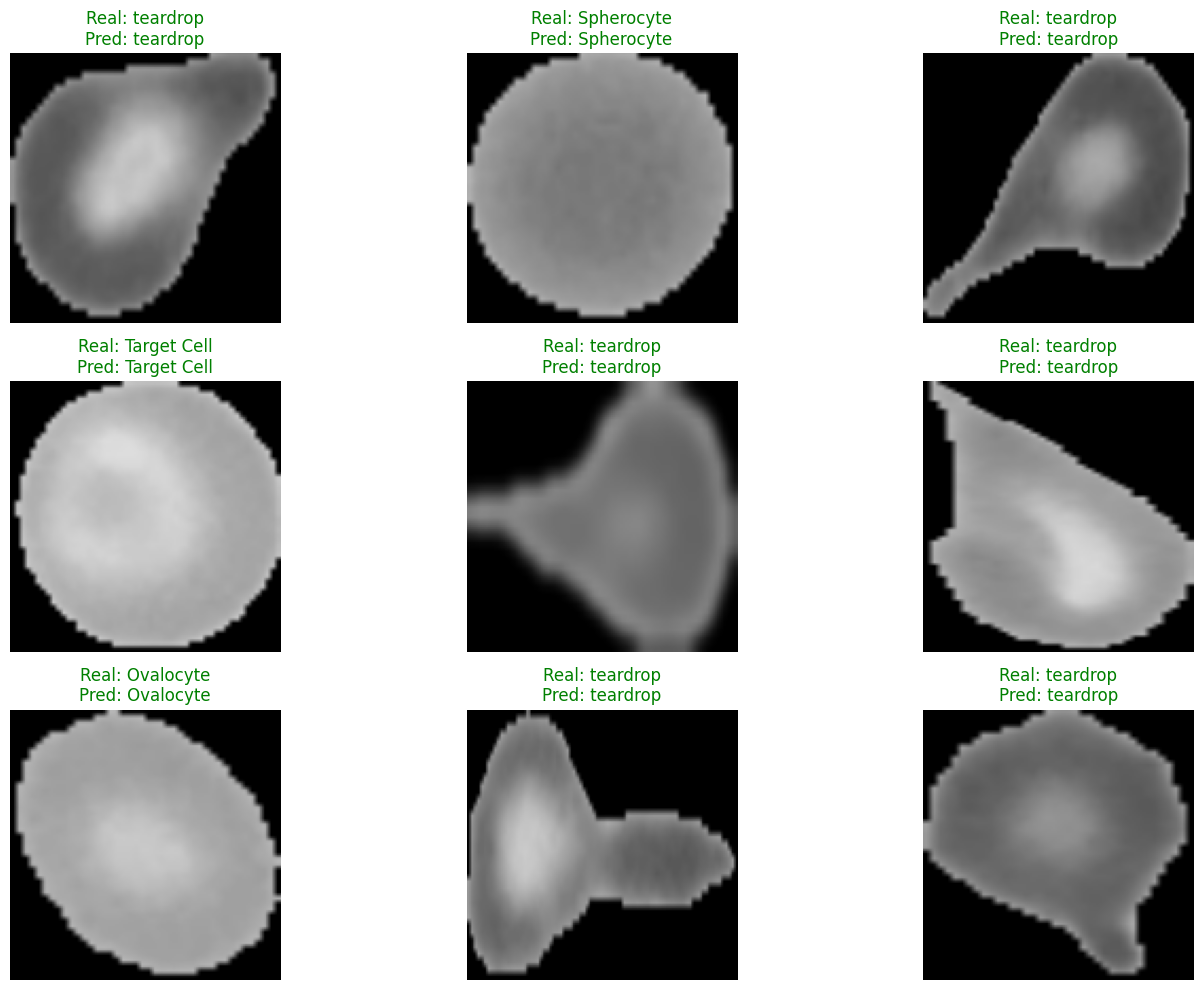

In [14]:
import numpy as np

# Retrieve a single batch of images and labels from the test set
image_batch, label_batch = next(iter(test_ds))

# Generate predictions
predictions = model.predict(image_batch)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

# Plot the results
plt.figure(figsize=(15, 10))
for i in range(9): # Display first 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    actual_name = class_names[true_labels[i]]
    predicted_name = class_names[pred_labels[i]]

    # Color green if correct, red if incorrect
    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Real: {actual_name}\nPred: {predicted_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 6. Transfer Learning with ResNet50
We will use a pre-trained ResNet50 model as a feature extractor and train it on our RBC dataset.

In [15]:
from tensorflow.keras.applications import ResNet50

# Base model with pre-trained weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False  # Freeze the base model layers

# Create the new model
resnet_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,083 (91.99 MB)

 Trainable params: 527,371 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [16]:
RESNET_EPOCHS = 3
RESNET_STEPS = 50

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=RESNET_EPOCHS,
    steps_per_epoch=RESNET_STEPS,
    validation_steps=20
)

# Evaluate ResNet on test set
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_ds)
print(f'\nResNet Test accuracy: {resnet_test_acc:.4f}')

Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.2694 - loss: 2.1473 - val_accuracy: 0.2344 - val_loss: 2.1368
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.2900 - loss: 2.1036 - val_accuracy: 0.2469 - val_loss: 2.0930
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.2937 - loss: 2.0744 - val_accuracy: 0.2422 - val_loss: 2.0513
195/195 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.2614 - loss: 2.0338

ResNet Test accuracy: 0.2614


### 7. ResNet50: Real vs Predicted
Let's visualize the results for the ResNet50 model on a sample batch from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


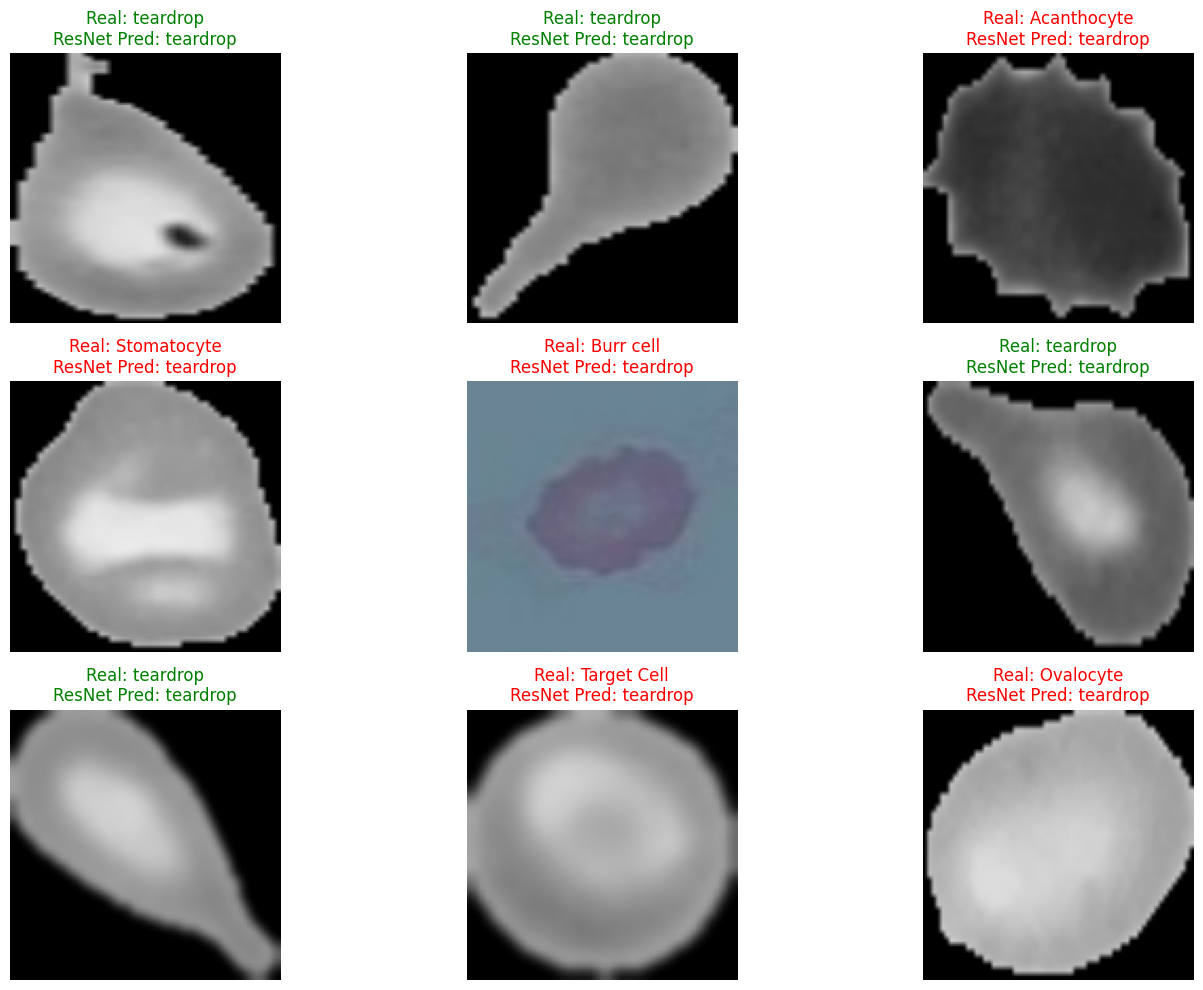

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from test_ds
image_batch, label_batch = next(iter(test_ds))

# Predict using ResNet
resnet_predictions = resnet_model.predict(image_batch)
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

plt.figure(figsize=(15, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    actual_name = class_names[true_labels[i]]
    predicted_name = class_names[resnet_pred_labels[i]]

    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Real: {actual_name}\nResNet Pred: {predicted_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 7. ResNet50: Real vs Predicted
Let's visualize the results for the ResNet50 model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


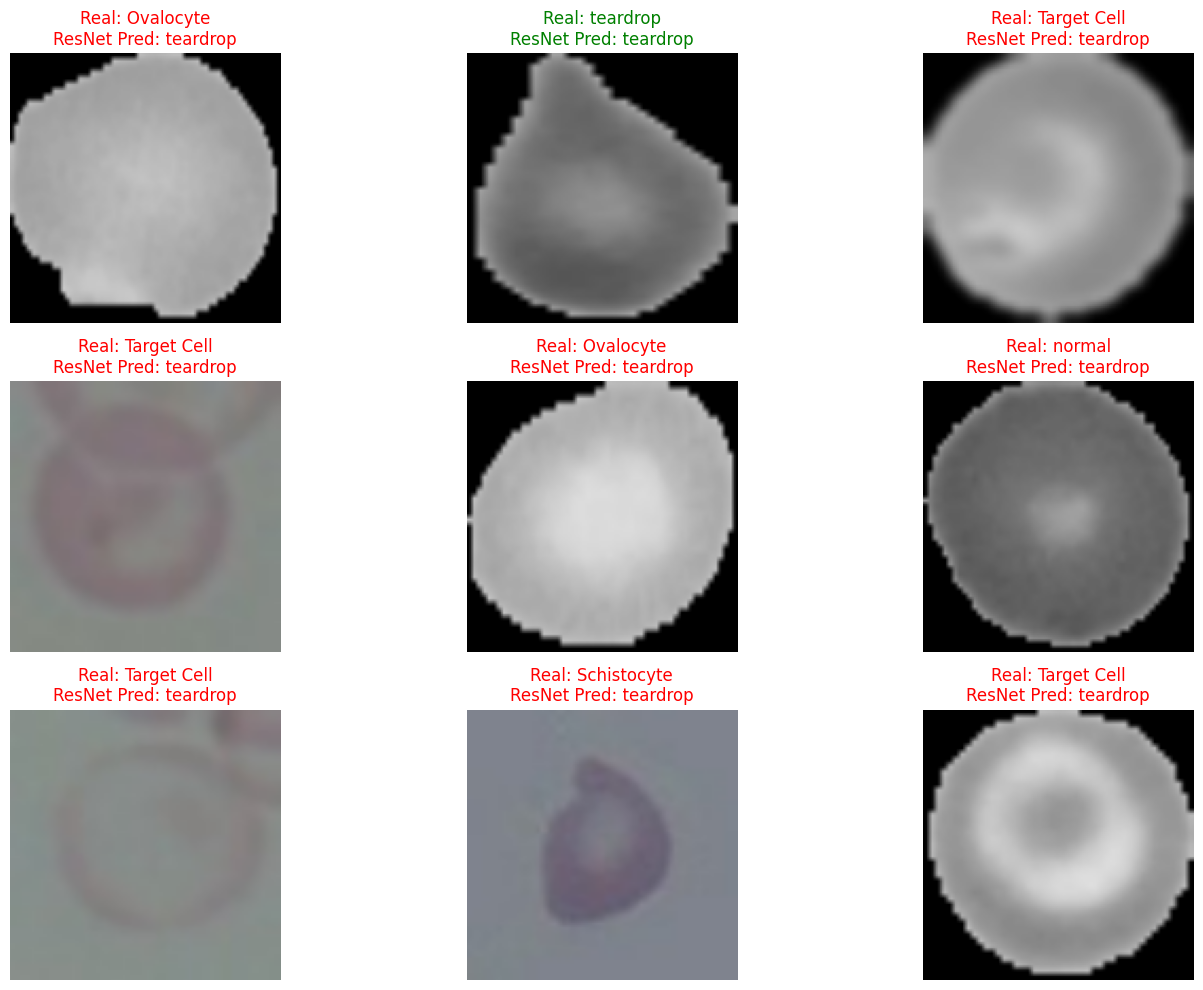

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch from test_ds
image_batch, label_batch = next(iter(test_ds))

# Predict using ResNet
resnet_predictions = resnet_model.predict(image_batch)
resnet_pred_labels = np.argmax(resnet_predictions, axis=1)
true_labels = np.argmax(label_batch, axis=1)

plt.figure(figsize=(15, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))

    actual_name = class_names[true_labels[i]]
    predicted_name = class_names[resnet_pred_labels[i]]

    color = 'green' if actual_name == predicted_name else 'red'

    plt.title(f"Real: {actual_name}\nResNet Pred: {predicted_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 8. Saving Models and Dataset
We will save the models to the local environment and create a zip archive of the extracted images.

In [19]:
# Save the models
model.save('rbc_cnn_model.keras')
resnet_model.save('rbc_resnet_model.keras')

print("Models saved as 'rbc_cnn_model.keras' and 'rbc_resnet_model.keras'")

# Zip the extracted dataset
import shutil
# The directory we want to zip is /content/extracted_images/RBC
shutil.make_archive('rbc_dataset_backup', 'zip', '/content/extracted_images/RBC')

print("Dataset compressed into 'rbc_dataset_backup.zip'")

Models saved as 'rbc_cnn_model.keras' and 'rbc_resnet_model.keras'
Dataset compressed into 'rbc_dataset_backup.zip'
